# ADP 27회

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

## 1 데이터 확인 및 전처리

In [2]:
d1= pd.read_csv('https://raw.githubusercontent.com/TKV-JONGIN/DataSet/refs/heads/main/ADP_27%ED%9A%8C_1%EB%B2%88_5%EB%B2%88%EC%9A%A9.csv')
d1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,Amount,Class
0,60.0,1.069141,0.043786,0.309867,1.316694,-0.462394,-0.857888,0.207904,-0.191270,0.056398,0.041567,-0.507358,-0.108666,-0.473257,0.452046,1.005675,0.185441,-0.439976,89.40,0
1,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,3.202033,-2.899907,-0.595222,-4.289254,0.389724,-1.140747,-2.830056,0.00,1
2,426.0,-1.932055,1.724618,1.288229,-0.396998,-0.140202,2.470521,-1.865298,-5.186855,0.794764,0.155379,0.034517,0.906738,-0.027172,-0.404303,-0.473949,0.274034,-0.222340,16.19,0
3,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,529.00,1
4,674.0,-0.719065,0.638954,0.686335,-0.023240,2.317890,3.871978,-0.312797,1.089780,-0.596925,-0.006142,-0.242883,-0.384491,0.109079,0.187565,1.823472,0.274346,-0.697730,22.00,0


## 1.1 
EDA 데이터 탐색하세요.

In [3]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1193 non-null   float64
 1   V1      1193 non-null   float64
 2   V2      1193 non-null   float64
 3   V3      1193 non-null   float64
 4   V4      1193 non-null   float64
 5   V5      1193 non-null   float64
 6   V6      1193 non-null   float64
 7   V7      1193 non-null   float64
 8   V8      1193 non-null   float64
 9   V9      1193 non-null   float64
 10  V10     1193 non-null   float64
 11  V11     1193 non-null   float64
 12  V12     1193 non-null   float64
 13  V13     1193 non-null   float64
 14  V14     1193 non-null   float64
 15  V15     1193 non-null   float64
 16  V16     1193 non-null   float64
 17  V17     1193 non-null   float64
 18  Amount  1193 non-null   float64
 19  Class   1193 non-null   int64  
dtypes: float64(19), int64(1)
memory usage: 186.5 KB


모두 연속형 변수(20)이며 결측치가 없는 것을 확인할 수 있다.  
여기서 class는 종속변수이다.  
다음으로 데이터의 분포를 시각화를 포함하여 수행한다.

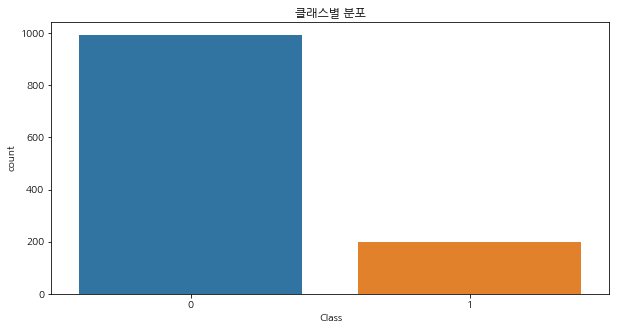

In [4]:
# 먼저 class 의 분포를 count plot으로 확인(카테고리 데이터)

plt.figure(figsize=(10, 5))
sns.countplot(d1['Class'])
plt.title('클래스별 분포')
plt.show()

In [5]:
d1['Class'].value_counts()

0    993
1    200
Name: Class, dtype: int64

In [6]:
d1['Class'].value_counts(normalize=True)

0    0.832355
1    0.167645
Name: Class, dtype: float64

이진 클래스이다. 클래스가 0인 데이터가 확연히 많으므로(약 88:17) 추후 해당 데이터를 가지고 분류모델을  
학습한다면 불균형 데이터에 대한 전처리가 필요할 것이다.   

다음으로 각 설명변수에 대한 분포를 알아본다.

In [7]:
d1.describe()[:-1].T

,count,mean,std,min,25%,50%,75%
Time,1193.0,91514.485331,47896.081947,60.000000,50265.000000,81797.000000,136995.000000
V1,1193.0,-0.755027,3.622262,-30.552380,-1.302600,-0.302521,1.249960
V2,1193.0,0.543730,2.663928,-33.644637,-0.435358,0.231973,1.112040
V3,1193.0,-1.148224,3.908787,-31.103685,-1.609339,-0.234204,0.811507
V4,1193.0,0.777816,2.345566,-4.294888,-0.610310,0.327567,1.335332
V5,1193.0,-0.409181,2.702077,-22.105532,-0.842184,-0.073622,0.684224
V6,1193.0,-0.283953,1.507579,-10.886820,-1.017863,-0.379633,0.302350
V7,1193.0,-0.852545,3.396565,-37.060311,-0.806043,-0.084983,0.464553
V8,1193.0,0.145026,2.471559,-37.353443,-0.219328,0.073036,0.454794
V9,1193.0,-0.446390,1.664075,-11.126624,-1.039740,-0.210455,0.452561


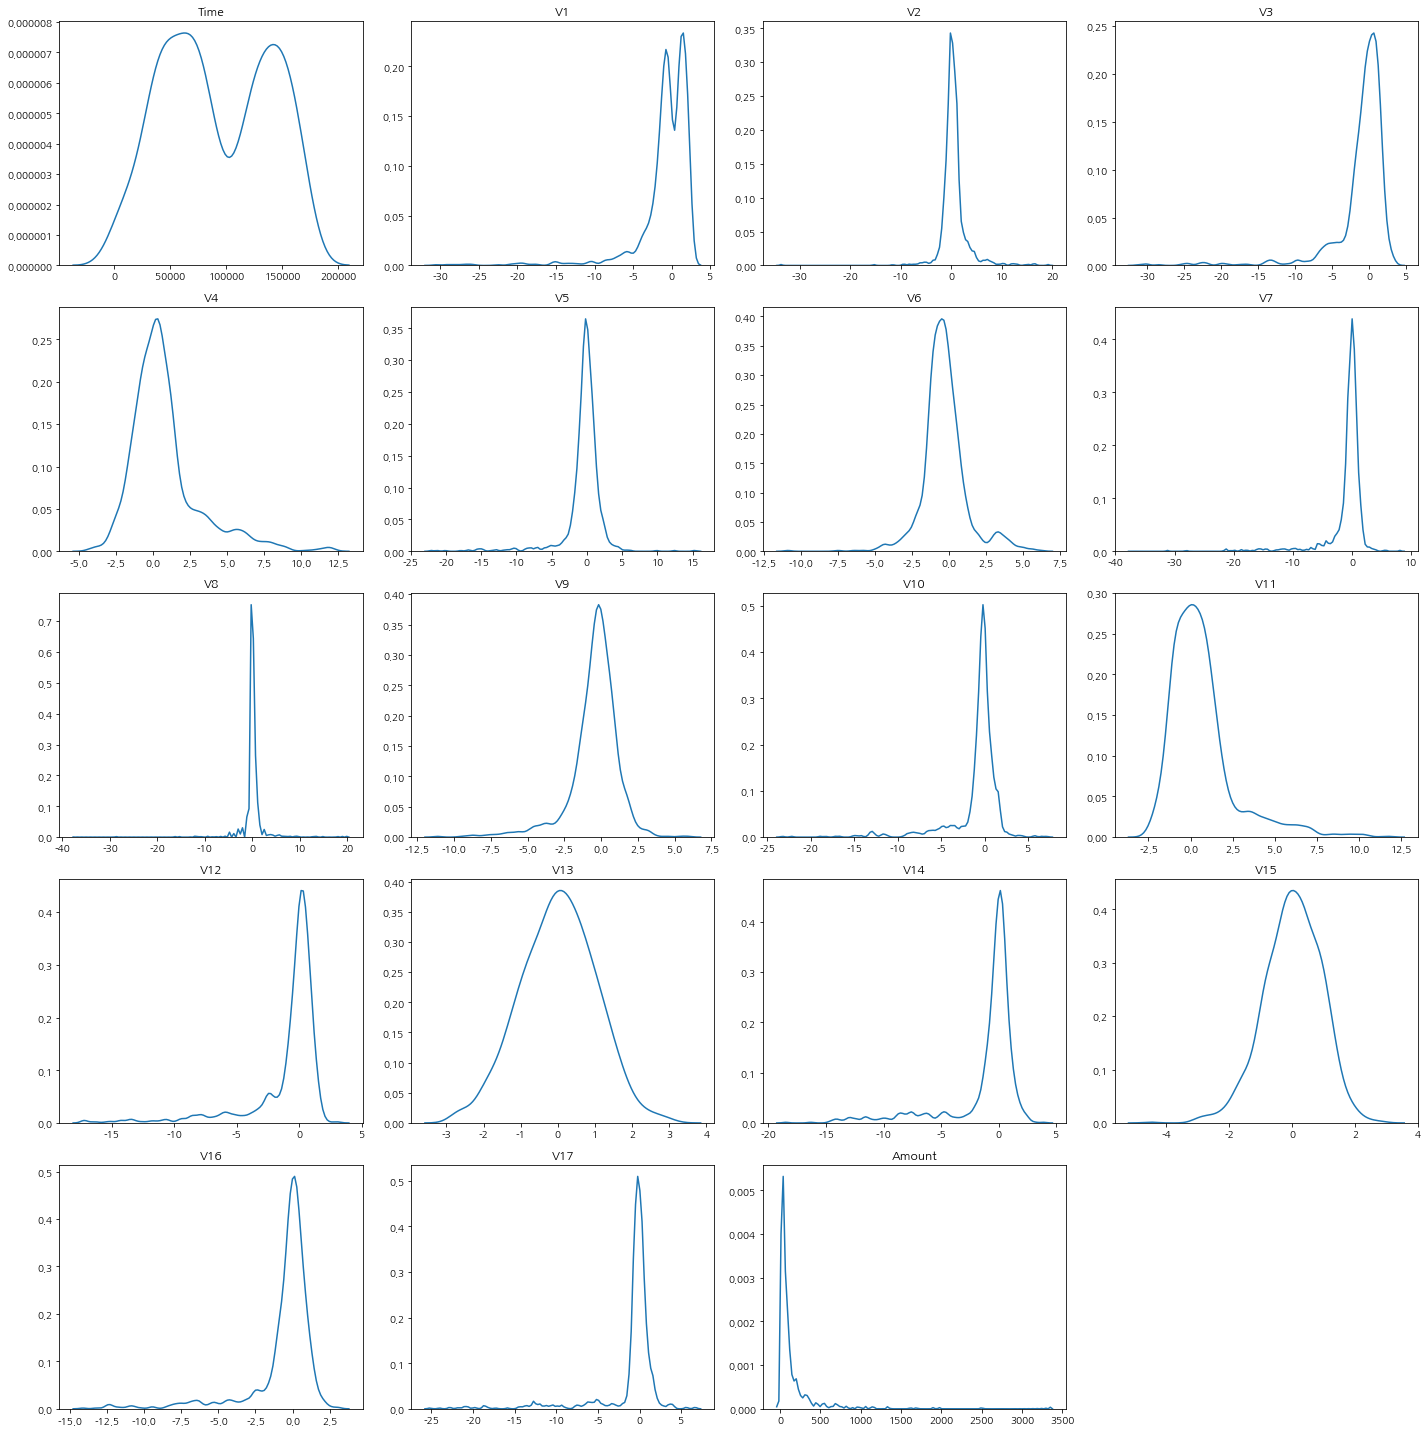

In [8]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
c_names = d1.columns[:-1]

for col, ax in zip(c_names, axes.flatten()):
    sns.kdeplot(data=d1[col], ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout()
axes[4, 3].remove()
plt.show()

- time은 쌍봉분포를 보이며, 5만과 15만 구간에 집중되어 있음  
- v4, 11, amount는 오른쪽으로 꼬리가 긴 양의 왜도  
- v13, 15는 평균이 0이며, 분산이 1인 정규분포에 가까운 분포를 보임
- v2, 8 등의 변수는 첨도가 높아서 특정 값에 분포가 집중되어 있음  
나머지 변수들은 대체로 음의 왜도를 보임

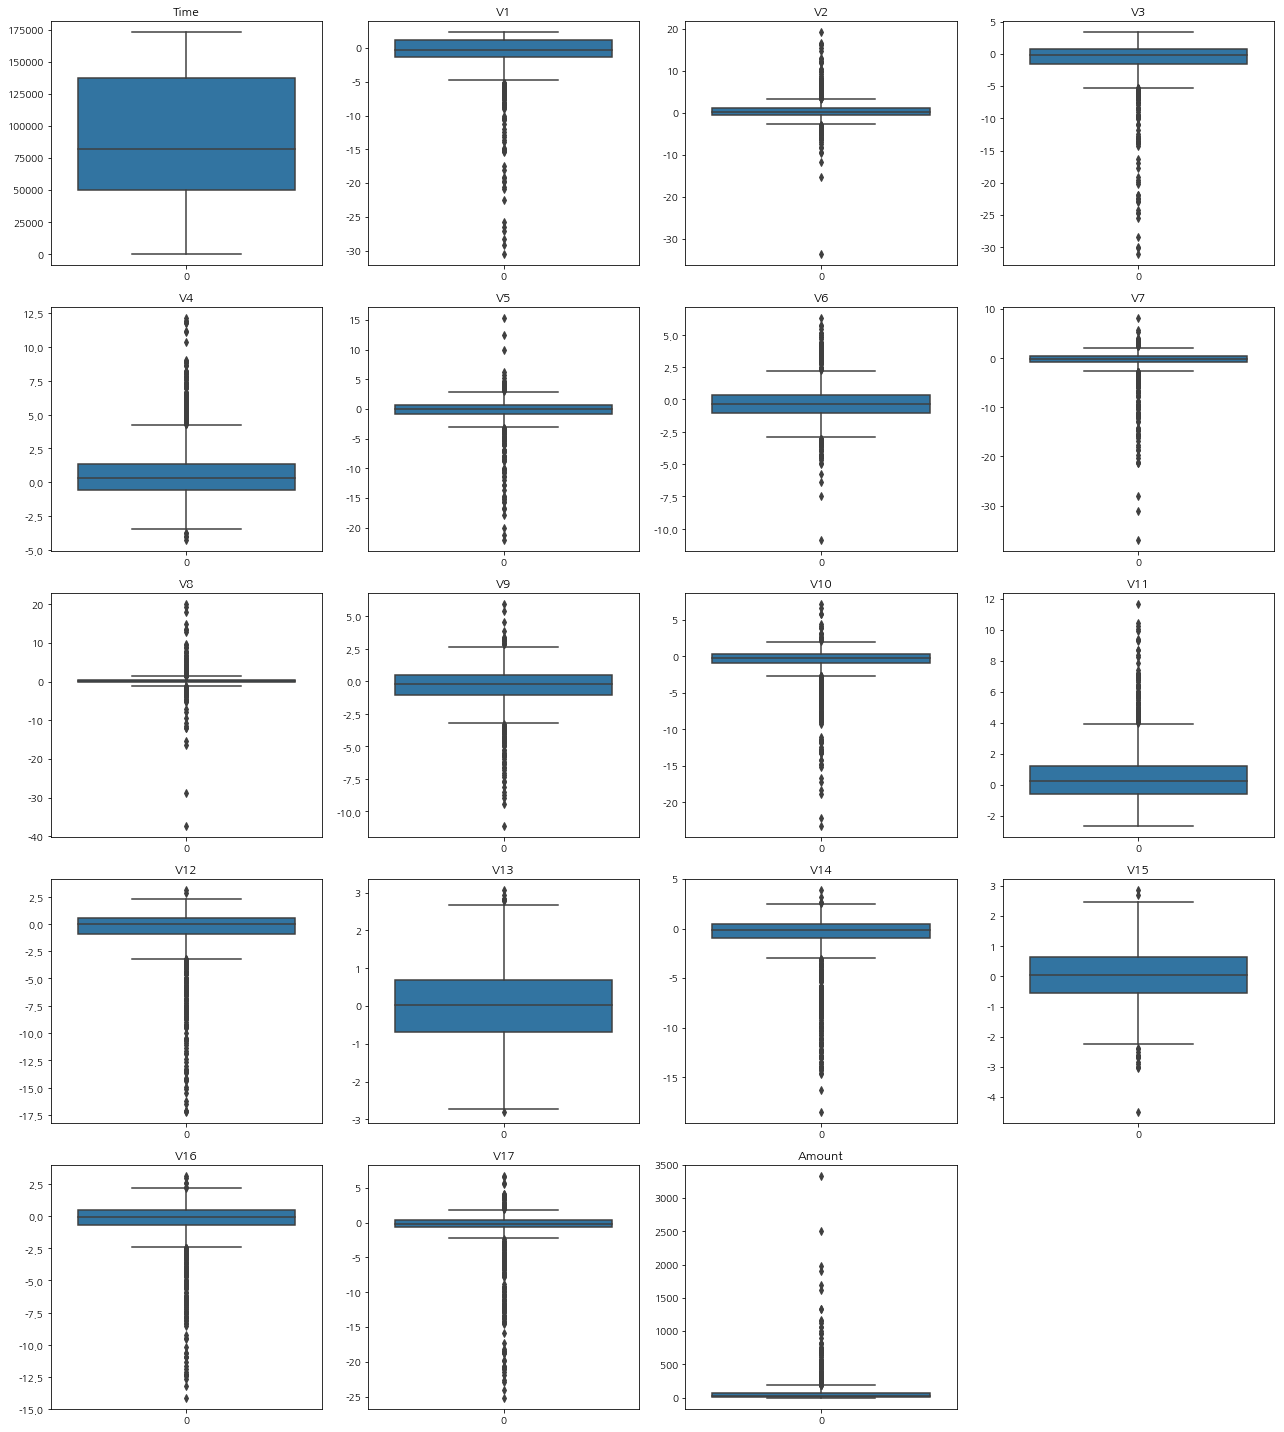

In [9]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
c_names = d1.columns[:-1]

for col, ax in zip(c_names, axes.flatten()):
    sns.boxplot(data=d1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
axes[4, 3].remove()
plt.show()

결측치는 없으며, 이상치에 대한 판별은 iqr, zscore+-3 방식으로 확인할 수는 있으나, 데이터에 대한 지식이 없으므로  
측정한 값에 대한 이상치 여부를 확인할 수 없다. 따라서 생략한다.

## 1.2 
변수간 상관관계를 시각화하고 전처리가 필요함을 설명하라

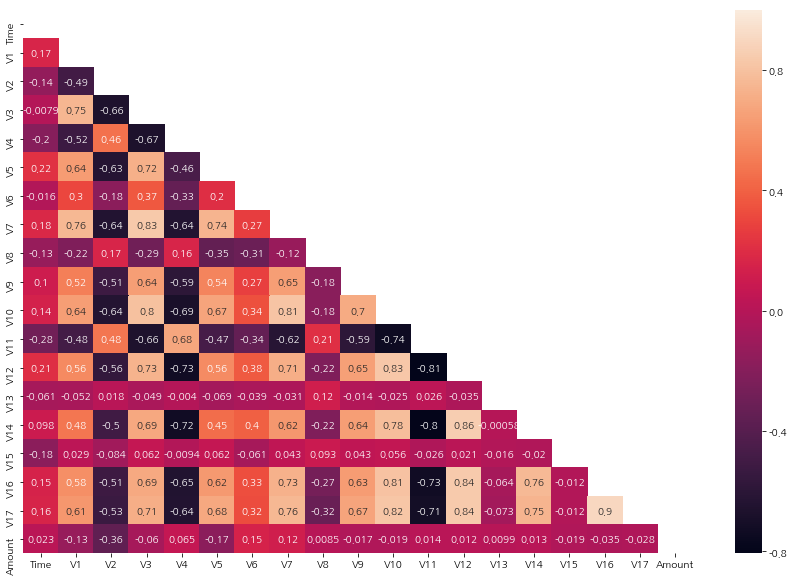

In [10]:
corr = d1.iloc[:, :-1].corr()

plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

In [11]:
corr_filtered = corr.where(np.abs(corr) >= 0.6)
display(corr_filtered)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,Amount
Time,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V1,NaN,1.000000,NaN,0.747294,NaN,0.639808,NaN,0.759509,NaN,NaN,0.640838,NaN,NaN,NaN,NaN,NaN,NaN,0.613414,NaN
V2,NaN,NaN,1.000000,-0.662717,NaN,-0.626978,NaN,-0.641787,NaN,NaN,-0.635937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V3,NaN,0.747294,-0.662717,1.000000,-0.669457,0.721634,NaN,0.830995,NaN,0.640404,0.800687,-0.661869,0.734679,NaN,0.689142,NaN,0.691389,0.711412,NaN
V4,NaN,NaN,NaN,-0.669457,1.000000,NaN,NaN,-0.638917,NaN,NaN,-0.686783,0.676151,-0.727734,NaN,-0.724656,NaN,-0.650353,-0.642360,NaN
V5,NaN,0.639808,-0.626978,0.721634,NaN,1.000000,NaN,0.743969,NaN,NaN,0.670030,NaN,NaN,NaN,NaN,NaN,0.624204,0.683379,NaN
V6,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V7,NaN,0.759509,-0.641787,0.830995,-0.638917,0.743969,NaN,1.000000,NaN,0.645007,0.810600,-0.617405,0.713087,NaN,0.617465,NaN,0.731554,0.759977,NaN
V8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V9,NaN,NaN,NaN,0.640404,NaN,NaN,NaN,0.645007,NaN,1.000000,0.702023,NaN,0.652466,NaN,0.640872,NaN,0.634698,0.674207,NaN


선형 상관분석인 피어슨 상관계분석을 통해 각 변수 간의 상관관계를 확인하였다.  
일반적으로 비교적 강한 상관관계 기준인 0.6을 기준으로 보았을 때 상당히 많은 변수 간 상관관계를 확인할 수 있다.  
피어슨 상관관계는 각 변수들 간 1:1 선형관계만 확인하기 때문에 vif를 통해 1:n 상관관계까지 확인 후 다중공선성 여부를 결정한다.  

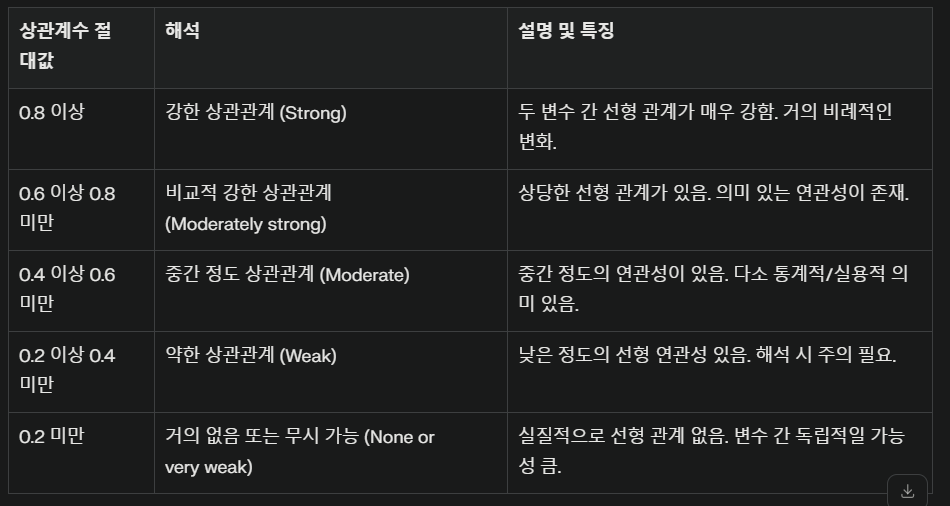

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = c_names
vif['vif'] = [variance_inflation_factor(d1[c_names], i) for i in range(len(c_names))]
display(vif[vif['vif']>=5].reset_index(drop=True))

,name,vif
0,V3,6.845459
1,V5,6.076872
2,V7,10.885920
3,V10,6.908535
4,V12,7.965567
5,V14,6.070439
6,V16,6.974822
7,V17,8.702978


일반적으로 vif는 10 이상일 시 강한 다중공선성을 가지며, 5~10 사이의 값은  
문제가 있다고 보며 변수 재선택이 권장된다.  
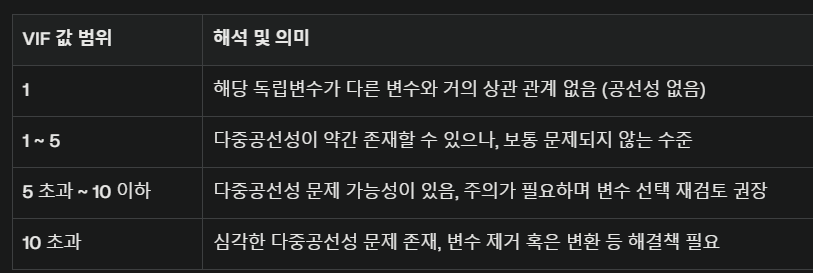

v7은 강한 다중공선성을 가지고 있으며, v3 등 6개의 변수에서 비교적 강한 다중공선성을 보인다.   

다중공선성이 높다는 것은 설명변수들 간 높은 상관관계를 가진다는 것을 뜻하며,  
이는 모델의 예측 안정성과 해석 가능성을 저하시킬 수 있으므로 PCA(주성분 분석)나  
변수 선택 기법 등을 통한 차원축소가 필요하다.

## 2 차원축소 (1번이어서)

### 2.1 차원축소 방법 2가지 이상 비교하고 한가지 선택하세요. 

주성분 분석(PCA)과 선형판별분석(LDA)를 비교한다.   
- PCA(비지도학습): 데이터의 분산을 최대한 보존하는 방향으로 새로운 축(주성분)을 찾아 상관관계가 있는 변수들을 새로운 축에 직교화 된  
  축으로 변환하여 중복을 제거하는 방식, 구현이 간편하며 각 변수들 간 설명력 정도를 직관적으로 확인이 가능하다는 장점이 있다.  
  (선형대수의  SVD 분해를 사용한다.)
- LDA(지도학습): 클래스 간 분리를 최대화하고, 클래스 내 분산을 최소화하는 축을 찾는다. 클래스 정보를 반영하여 반영하여 분류성능이  
  높은 저차원데이터로 모델학습을 수행한다.   
  (충분하고 균형 잡힌 레이블 데이터가 있을 때 뛰어난 분류 성능과 차원 축소 효과를 보임)  


여기서는 PCA를 선택한다.

### 2.2 추천한 한 가지를 실제로 수행하고 선택한 이유 설명

해당문제는 레이블이 불균형하여 클래스 간 분리 설명모델보다는, 데이터 자체를 적절히 잘 설명하는 저차원 모델이 필요하므로 PCA를 활용  

PCA는 각 변수 간 거리에 민감한 기법이므로 스케일링(여기서는 standard scaler)을 수행하며, 데이터 누수(leak)를 예방하기 위해  
train, test set 으로 분할 → PCA를 수행한다.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


X = d1.drop(columns=['Class'])
Y = d1['Class']

# 데이터 분할: 테스트셋 20%
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

sc = StandardScaler()
# 스케일링
train_X = sc.fit_transform(train_X)
test_X = sc.transform(test_X)

pca = PCA(n_components=0.8, svd_solver='auto') # 80%이상을 만족하는 축 갯수 선택

train = pca.fit_transform(train_X)

rs = pd.DataFrame({'고윳값': pca.singular_values_, 
                  '분산설명력': pca.explained_variance_ratio_, 
                  '누적분산설명력': np.cumsum(pca.explained_variance_ratio_)})


display(rs)

,고윳값,분산설명력,누적분산설명력
0,90.455828,0.481706,0.481706
1,34.727255,0.070999,0.552705
2,33.899363,0.067654,0.620358
3,32.103257,0.060675,0.681033
4,31.626342,0.058885,0.739918
5,28.790407,0.048798,0.788716
6,26.641539,0.041786,0.830502


pca를 통해 전체데이터 분산을 약 83% 설명하는 새로운 주성분 축 7개가 선택되었다.  
새로운 feature(주성분축)들이 기존 변수에서 얼마나 영향을 받는지 확인해본다.

In [29]:
# 고유벡터 요약
e_vector = pd.DataFrame(pca.components_, 
                       index=['comp'+str(i) for i in range(1, rs.shape[0]+1)], 
                       columns=X.columns)

e_vector

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,Amount
comp1,-0.061432,-0.241566,0.217093,-0.290814,0.255392,-0.245084,-0.134107,-0.287063,0.086718,-0.250383,-0.303937,0.273442,-0.300422,0.009898,-0.281790,-0.011429,-0.292645,-0.295972,-0.000832
comp2,0.321846,-0.047024,0.210370,-0.109360,-0.028039,-0.120867,0.414373,-0.155765,-0.482225,-0.087133,-0.078282,-0.090679,0.047983,-0.252563,0.075895,-0.540752,0.051002,0.042463,0.058944
comp3,0.152405,-0.141545,-0.443275,-0.056569,0.074412,-0.092876,0.012694,0.115913,0.122124,-0.045960,0.010696,-0.005939,0.012169,0.071071,0.003216,-0.118176,-0.056867,-0.059105,0.828376
comp4,-0.686588,-0.099400,0.098651,0.089112,-0.052974,-0.260262,0.507974,-0.114641,-0.145412,0.020554,-0.004263,-0.015348,0.038104,0.183469,0.175155,0.193980,-0.003174,-0.014705,0.183993
comp5,0.148656,-0.148160,0.213203,-0.138635,-0.236920,-0.329059,-0.055775,-0.064296,0.442134,0.069162,0.045489,-0.210966,0.138382,0.537228,0.222486,-0.317373,0.054657,-0.008040,-0.108336
comp6,0.001750,-0.173242,0.136195,-0.119493,-0.128191,-0.294815,-0.029353,-0.051921,0.378990,-0.031341,0.033805,-0.195477,0.157295,-0.722517,0.156263,0.245843,0.091577,0.044930,0.065158
comp7,0.388521,-0.306667,-0.003264,-0.191982,-0.058970,0.003275,-0.043701,-0.229893,-0.383949,0.032668,-0.030625,-0.217380,0.100784,0.244225,0.078944,0.620975,0.020955,0.021495,0.025838


각 주성분 생성 시 기존 변수가 얼마나 기여하였는지에 대해 알 수 있다.  
절대값이 클 수록 그 변수는 주성분의 생성에 크게 기여하며, 부호는 기여방향성을 나타낸다. 

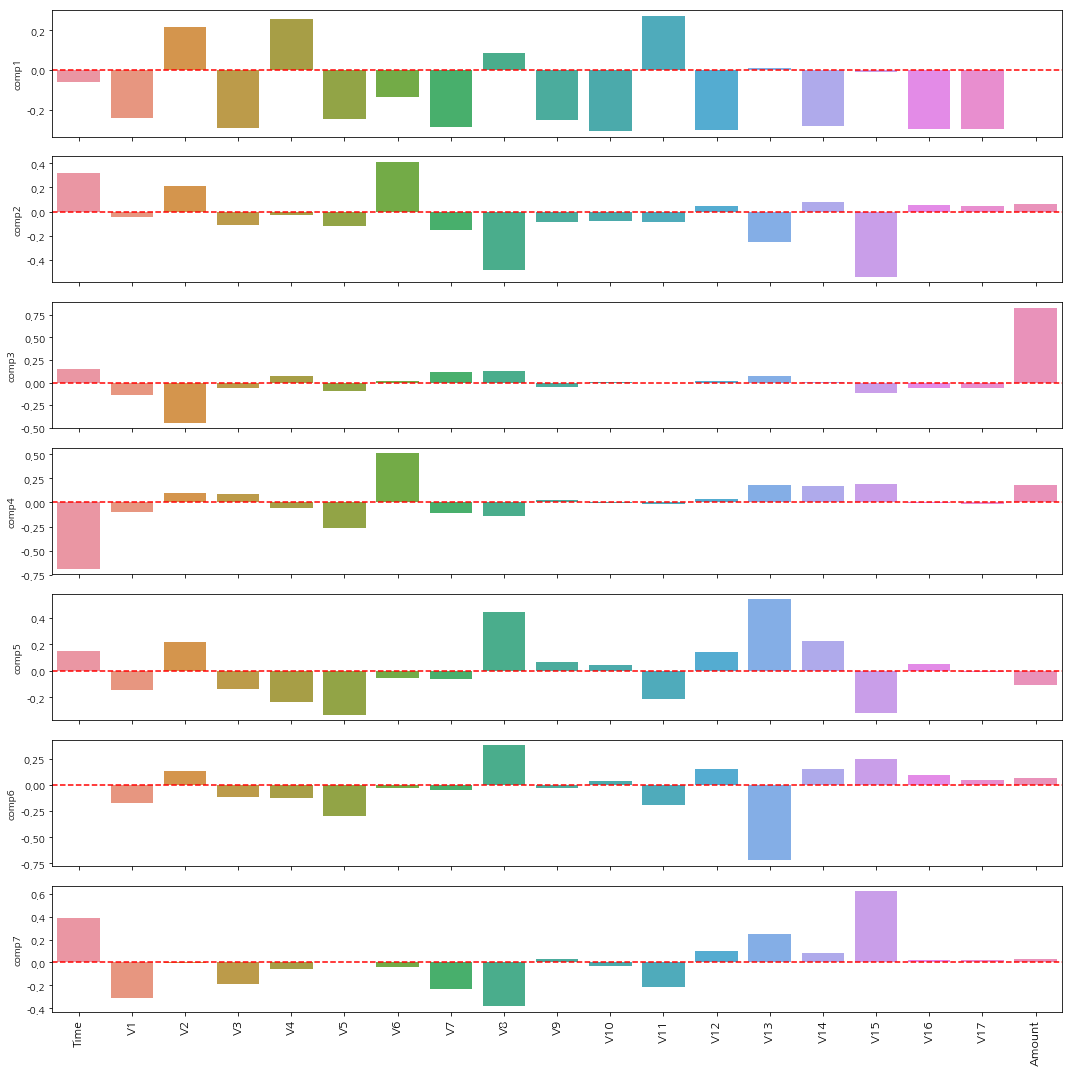

In [30]:
#시각화
fig, axes = plt.subplots(rs.shape[0], 1, figsize=(15, 15))

for idx, ax in zip(e_vector.index, axes):
    sns.barplot(x=e_vector.columns, y=e_vector.loc[idx], ax=ax)
    ax.axhline(y=0, color='r', ls='--')
    if idx != 'comp7':
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(list(e_vector.columns), rotation=90, fontsize=12)
plt.tight_layout()
plt.show()

- comp7을 보면 v15가 양의 방향으로 크게 기여하였으며, v1, v7 등의 변수는 음의 방향으로 기여한 것을 알 수 있다.   

이렇게 주성분 분석을 통해 생성된 변수(주성분축)는 서로 직교하므로 다중공선성이 제거되게 된다.  
vif도 1이 나온다. 

In [32]:
# pca로 변환하여 저장
train_X = pca.fit_transform(train_X)
test_X = pca.transform(test_X)

## 3 오버샘플링/언더샘플링 (1번이어서)

### 3.1 오버샘플링과 언더샘플링 장단점 비교 및 선택 구현

해당 데이터는 클래스간 불균형이 심한 데이터이다. 이대로 학습을 수행한다면 minor calss를 잘 예측해내지 못하므로 마이너 클래스의 데이터 수를 늘려주는 오버샘플링 또는 메이저 클래스 데이터 수를 줄이는 언더샘플링을 실시해야 제대로 된 모델학습 및 예측이 가능하다.  

1. 오버샘플링: 소수레이블에 해당하는 데이터를 늘리는 방식으로 Random Oversampling, SMOTE, ADASYN 등이 있다.   
    - 장점: 데이터의 정보손실이 없으며, 소수 클래스의 패턴학습이 가능
    - 단점: 랜덤 오버샘플링처럼 소수 데이터를 단순 복제할 경우 과적합 위험
2. 언더샘플링: 다수 레이블에 해당하는 데이터를 제거하여 레이블 간 균형을 맞추는 방식으로 Random Undersampling, Nearmiss 등이 있음
- 장점: 전체 데이터 수가 줄어들어 연산량이 줄어듬
- 단점: 정보 손실이 있음

해당 데이터셋은 소수레이블이 크게 부족하므로 언더샘플링을 실행 시 major calss의 많은 정보손실이 있을 수 있으므로 오버샘플링을 시행한다. 또한 컴퓨팅 파워가 뒷받침만 된다면 정보의 손실이 발생하지 않는 방향으로 학습이 진행되는 것이 적절하다.  

여기서는 비지도학습인 kmeans의 기법을 적용한 SMOTE 방식인 Kmeans SMOTE를 활용한다.

In [33]:
from collections import Counter
from imblearn.over_sampling import KMeansSMOTE

km = KMeansSMOTE(random_state=42)
train_X_s, train_Y_s = km.fit_resample(train_X, train_Y)

print(f"리샘플 클래스별 데이터수:{Counter(train_Y_s)}")

리샘플 클래스별 데이터수:Counter({1: 740, 0: 739})


마이너 클래스의 데이터 수가 증가하여 두 클래스의 비율이 동일해진 것을 확인할 수 있다.

### 3.2 구현 및 알고리즘 2가지 이상 비교, 성능 측정

이 문제는 이진 클래스를 예측해내는 지도학습, 분류 문제이다.  

randomforest와 성능 비교군으로 logistic regression을 구현한다.  

1. 랜덤 포레스트는 다수의 결정 트리를 앙상블하여 예측 성능을 향상시키는 트리 기반 모델로, 특히 변수 중요도 평가와 강건성 측면에서  
   뛰어난 성능을 보임. 높은 차원 데이터에서도 특성 중요도 기반 가중치 조정 등을 통해 모델의 효율성을 높일 수 있으며, 실제 다양한   
   자료에서 높은 정확도와 안정성을 입증받고 있음. 이는 랜덤 포레스트가 복잡한 데이터 구조를 효과적으로 학습할 수 있기 때문임
   
2. 로지스틱 회귀는 선형 모델로, 실제값과 예측값 간의 오차 제곱합이 최소가 되도록 선형식을 학습하며 이를 바탕으로 확률을 예측하는   
   방식. 구현이 간단하고 해석이 명확하다는 이점이 있으며, 회귀 계수의 크기로 변수의 영향력을 파악할 수 있음.   
   특히 클래스 확률을 직접 추정하기 때문에 의사결정 과정에서 투명성이 요구되는 상황에 적합함.   
   다만 선형 경계에 기반하므로 데이터가 복잡하거나 변수 간 비선형 관계가 클 경우 성능 저하가 발생할 수 있음

train set을 활용하여 모델 학습 후 test set을 이용하여 성능을 측정 후 비교한다. 성능지표는 분류모델 성능지표인 accuracy, recall, precision, f1 score를 활용한다. 

(recall-precision), 정밀도와 재현율의 조화평균인 f1 score는 불균형 데이터의 성능지표로 많이 활용되며, 데이터가 불균형한 상태로   
모델이 적합되었다면 마이너 클래스도 majority class로 판별하기 때문이다. minority class의 성능지표에 집중해서 보는 방법도 있다.

### 3.3 현재까지 전처리한 데이터를 통해 모델 수행 후 결과 분석

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


lr = LogisticRegressionCV(random_state=42)
rf = RandomForestClassifier(max_depth=5, random_state=42)

lr.fit(train_X_s, train_Y_s)
rf.fit(train_X_s, train_Y_s)

m_list = {'Logistic Regression': lr, 
         'RandomForestCV': rf}

dt_list = [('train', train_X_s, train_Y_s), ('test', test_X, test_Y)]
for name, model in zip(m_list.keys(), m_list.values()):
    print(f"모델명: {name} 학습")
    d_name = ['train', 'test']
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        accuracy = accuracy_score(y, pred)
        f1 = f1_score(y, pred)
        
        print(f"<--[{d_name}]-->")
        print(f"- accuracy score: {accuracy:.3f}")
        print(f"- f1 score: {f1:.3f}")
        print(classification_report(y, pred))
    print('\n')

모델명: Logistic Regression 학습
<--[train]-->
- accuracy score: 0.979
- f1 score: 0.979
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       739
           1       0.99      0.96      0.98       740

    accuracy                           0.98      1479
   macro avg       0.98      0.98      0.98      1479
weighted avg       0.98      0.98      0.98      1479

<--[test]-->
- accuracy score: 0.980
- f1 score: 0.929
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       254
           1       1.00      0.87      0.93        45

    accuracy                           0.98       299
   macro avg       0.99      0.93      0.96       299
weighted avg       0.98      0.98      0.98       299



모델명: RandomForestCV 학습
<--[train]-->
- accuracy score: 0.987
- f1 score: 0.987
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       739
           1     

두 모델 모두 accuracy, precision, recall, f1_score 0.9 이상으로 높은 예측 성능을 보여준다.  
train/test set 간 과적합도 없다.(다만 오버샘플링 전 minority class 였던 레이블 1의 recall(재현율)이 0.87로 다소 낮게 측정)  
두 모델의 성능이 대동소이하므로 구현이 간편하고 학습시간이 짦은 Logistic regression을 사용모델로 채택한다.

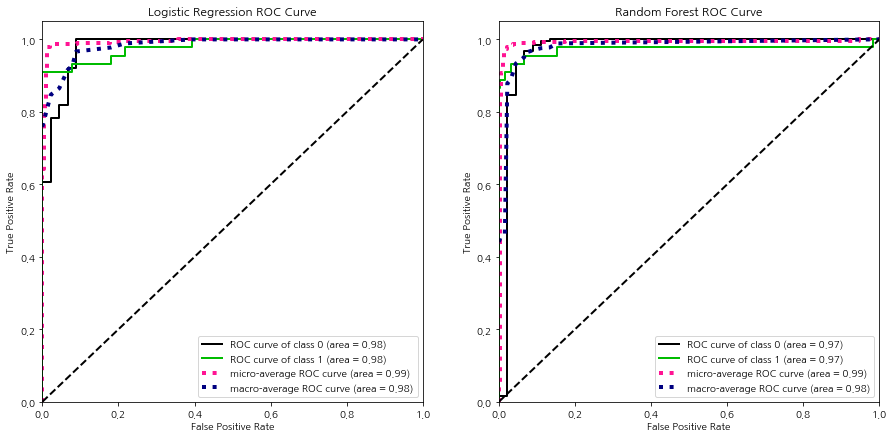

In [76]:
import scikitplot as skplt
proba1 = lr.predict_proba(test_X)
proba2 = rf.predict_proba(test_X)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
skplt.metrics.plot_roc_curve(test_Y, proba1, ax=ax[0])
skplt.metrics.plot_roc_curve(test_Y, proba2, ax=ax[1])
ax[0].set_title('Logistic Regression ROC Curve')
ax[1].set_title('Random Forest ROC Curve')
plt.show()

## 4 이상탐지

### 4.1 이상탐지 모델 2가지 이상 기술, 장/단점 설명

이상탐지(Anomaly Detection)는 데이터에서 정상적인 패턴과 다른, 예외적이며 이례적인 관측값(이상치, 이상 이벤트)을 식별하는 분석기법  
대표적으로 신용카드 사기, 네트워크 침입, 제조 결함, 의료 이상신호, 금융 사기 등 다양한 분야에서 활용  


이상탐지는 보통 비지도학습 방법이 많이 쓰이는데 현실 세계에서는 레이블링 된 이상치 데이터가 아예 없거나 충분하지 않기 때문임.  
다음의 두 비지도학습 모델을 고려한다. 두 모델 모두 군집분석 모델이다.  
1. DBSCAN: 지정된 거리 내의 이웃 point의 밀도를 기준으로 핵심점/경계점/잡음을 구분해 군집 형성, 임의 모양 군집탐지가 가능하며, 이상치가 자동 식별되는 장점이 있으나 거리, 최소 군집 point 하이퍼파라미터 설정에 민감하고 최적화가 어려움
2. KMeans clustering: 사용자 지정 K개의 중심점을 기반으로 데이터를 가장 가까운 중심으로 군집화하고, 중심을 재계산하는 과정을 반복해 안정적인 군집을 찾는 알고리즘으로 구현 및 계산이 단순하고 빠르며, 결과 해석이 용이하다는 장점이 있으나 비구형 데이터에 부적합하고, 이상치에 민감하며, k값이 미리 지정되어야 함  

여기서는 결과해석이 용이하며, 구현이 간편한 Kmeans clustering을 선택한다.  

### 4.2 2번에서 만든 데이터로 한 가지 이상탐지 모델을 구현하고, 3번에서 만든 모델과 비교

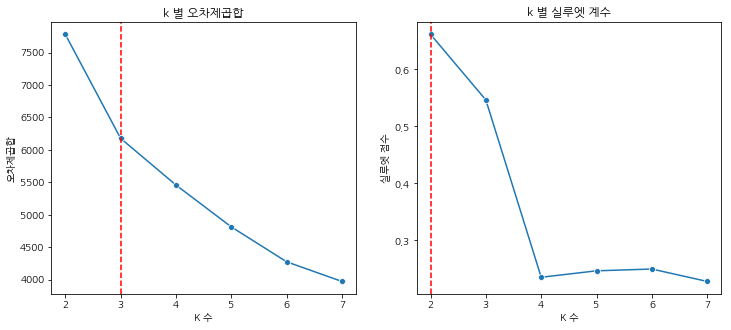

In [140]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

er = []
sil = []

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42).fit(train_X)
    er.append(km.inertia_) #오차제곱합
    sil.append(silhouette_score(train_X, km.labels_))

sns.lineplot(list(range(2, 8)), er, marker='o', ax=ax[0])
sns.lineplot(list(range(2, 8)), sil, marker='o', ax=ax[1])
ax[0].set_title('k 별 오차제곱합')
ax[0].set_xlabel('K 수')
ax[0].set_ylabel('오차제곱합')
ax[1].set_title('k 별 실루엣 계수')
ax[1].set_xlabel('K 수')
ax[1].set_ylabel('실루엣 점수')
ax[0].axvline(x=3, ls='--', color='r')
ax[1].axvline(x=2, ls='--', color='r')
plt.show()

오차제곱합과 실루엣 계수의 scree plot을 통해 최적의 k를 결정한다.  
오차제곱합의 엘보우 지점은 2이며, 실루엣 점수가 가장 높음, 또한 3번 문제의 결과와  
비교를 위해(실제 데이터는 이진분류 문제이므로) k=2로 설정한다.

In [141]:
kmeans = KMeans(n_clusters=2, random_state=42)
dist = kmeans.fit_transform(train_X) #각 클러스터 센터와의 거리
label = kmeans.labels_
print(Counter(label))

Counter({0: 811, 1: 83})


k=2로 클러스터 비지도 학습 후 위의 2개의 군집으로 분류되었다.  
0번 클러스터의 비율이 높게 분류되었다. 

In [142]:
#군집별 중심점
centers = pd.DataFrame(kmeans.cluster_centers_, index=["cluster"+str(i) for i in range(2)])
display(centers)

,0,1,2,3,4,5,6
cluster0,-0.849474,0.019954,0.00370,0.024117,0.030653,0.024457,0.008949
cluster1,8.300284,-0.194969,-0.03615,-0.235647,-0.299511,-0.238973,-0.087441


In [143]:
# 실루엣 계수, completeness score: 테스트 셋 기준 평가
from sklearn.metrics import completeness_score
s_score = silhouette_score(train_X, label)
c_score = completeness_score(train_Y, label)

print(f"실루엣 점수: {s_score:.3f}")
print(f"completeness 점수: {c_score:.3f}")

실루엣 점수: 0.661
completeness 점수: 0.613


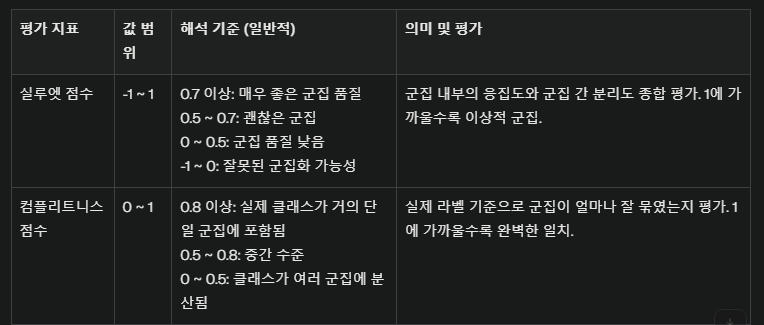

train set으로 비지도학습한 모델의 군집품질 평가결과, 두 평가지표 모두 양호한 수준
- 실루엣 점수(군집 내부의 응집도와 군집 간 분리도 평가): 양호
- 컴플리트니스 점수(실제 레이블 기준 군집 학습평가): 중간 수준

비지도 학습을 수행한 결과에서 라벨 1을 이상치 데이터로 정의한다.   
이후 test set의 레이블을 예측 후 실제 레이블과 비교한다.  
평가지표는 이전에 사용했던 accuracy, f1_socre, precision, recall을 종합적으로  
활용한다. 

In [145]:
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

for name, x, y in dt_list:
    pred = kmeans.predict(x)
    accuracy = accuracy_score(y, pred)
    f1 = f1_score(y, pred)

    print(f"<--[{name}]-->")
    print(f"- accuracy score: {accuracy:.3f}")
    print(f"- f1 score: {f1:.3f}")
    print(classification_report(y, pred))

<--[train]-->
- accuracy score: 0.919
- f1 score: 0.697
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       739
           1       1.00      0.54      0.70       155

    accuracy                           0.92       894
   macro avg       0.96      0.77      0.83       894
weighted avg       0.93      0.92      0.91       894

<--[test]-->
- accuracy score: 0.930
- f1 score: 0.696
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       254
           1       1.00      0.53      0.70        45

    accuracy                           0.93       299
   macro avg       0.96      0.77      0.83       299
weighted avg       0.94      0.93      0.92       299



모델 학습결과를 분류모델의 성능지표로 확인하였다.  

train, test set의 정확도는 0.9 이상으로 높으나, 레이블 1의 성능지표가 매우 낮게 측정되었다.  
특히 train/test set 모두 이상치의 레이블 1의 재현율(recall)이 0.53인데, 이는 실제 레이블 1을 절반 수준으로밖에 예측해내지 못했다는  
의미이다.(동전 던지기 수준) 절반의 실제레이블 1은 majority class인 0으로 오분류되었다.   
이를 개선하기 위해 거리의 threshold를 조정하는 등의 방법이 필요할 것이다. 

In [250]:
threshold = np.percentile(dist.min(axis=1), 81)
test_dist = kmeans.transform(test_X)

print(f"거리 임계치: {threshold}")
# majority class인 0의 거리가 임계치 이상이면 1로 판별
new_pred1 = (dist[:, 0] > threshold).astype(int)
new_pred2 = (test_dist[:, 0] > threshold).astype(int)
print("[train set]")
print(classification_report(train_Y, new_pred1))
print("[test set]")
print(classification_report(test_Y, new_pred2))

거리 임계치: 3.0767283257371205
[train set]
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       739
           1       0.71      0.85      0.77       155

    accuracy                           0.91       894
   macro avg       0.84      0.89      0.86       894
weighted avg       0.92      0.91      0.92       894

[test set]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       254
           1       0.75      0.91      0.82        45

    accuracy                           0.94       299
   macro avg       0.86      0.93      0.89       299
weighted avg       0.95      0.94      0.94       299



거리 임계치를 81%로 조정하여 임계치 이상인 거리에 해당하는 레코드를 레이블 1로 분류함으로써 분류성능이 향상된 것을 볼 수 있다.   
train, test set 학습결과 모두 과적합이 없으며, 기존 대비해서 이상치 탐지 성능이 대폭 향상되었다.   

두 클래스를 적절히 잘 분류해내며, 과적합이 없고 특히 기존 대비 racall(test set 기준) 성능이 0.53 -> 0.91로 크게 향상되어  
실제 이상치인 레이블 1을 잘 예측해냄을 알 수 있다.

### 4.3 데이터분석가 관점에서 3번에서 만든 모델과 4번에서 만든 모델 설명

3번에서 생성한 모델은 불균형 데이터를 오버샘플링을 통해 동일한 비율의 데이터로 증가시켜 지도학습, 이진분류한 모델이며,  
4번에서 생성한 모델은 레이블이 필요없는 비지도학습 클러스터링을 통해 이상치 탐지로서 minor class인 1을 판별해 낸 결과이다.  

레이블이 제공되며 오버샘플링으로 성능이 보완되는 문제라면 오버샘플링을 통해 지도학습을 실시하는 것이 적합하겠으며,  
레이블이 제공되지 않거나, 이상치가 극히 적어서 오버샘플링으로도 낮은 성능을 보이는 문제라면 비지도학습을 통한  
이상치 탐지가 적절하다고 하겠다. 이상치 탐지 성능이 낮다면 임계치를 적절히 조절함으로써 판별성능을 높일 수 있을 것이다. 

## 5  
2년 전 제품 생산량이 100,000개, 1년 전 제품 생산량이 150,000개, 그 후 팩토리 기술의 상승으로 제품 생산량이 250,000개 되었을 때, 연평균 상승률의 대푯값을 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

In [82]:
#기하평균 문제
from scipy.stats import gmean

# 먼저 년도별 상승률을 구해야 한다. +1한 것임
df = np.array([150000, 250000])/np.array([100000, 150000])

g_mean = gmean(df)-1

print(f"연평균 상승률[기하평균]: {g_mean*100:.2f} %")

연평균 상승률[기하평균]: 58.11 %


In [87]:
#수기계산

g2 = np.prod(df)**(1/2)-1

print(f"수기계산: {g2*100:.2f} %")

수기계산: 58.11 %


## 6
12건의 광고 시간 측정. 평균 15.5초, 분산 3.2초 일때 90% 신뢰구간은?



In [99]:
from scipy.stats import t

n= 12 #12건의 광고
m = 15.5 #평균
v = 3.2 #분산
a = 0.1 #신뢰구간
dof = n-1 # 자유도

se = np.sqrt(v)/np.sqrt(n) #표본표준오차
z = t.ppf(1-a/2, dof) #단측 신뢰계수
me = se*z #허용오차

print(f"90% 신뢰구간: {m-me:.3f} ~ {m+me:.3f}")

90% 신뢰구간: 14.573 ~ 16.427


12건의 광고시간 측정으로 확인된 평균과 분산은 모집단을 대표한다고 볼 수 없으므로 표본평균, 분산으로 보아야 한다.  
따라서 t 분포를 통해 90% 신뢰구간을 구한다.  
여기서 자유도는 t 분포의 자유도인 n-1을 사용한다.  

이를 통해 표본표준오차, 신뢰계수(단측), 허용오차를 순차적으로 구하고, 표본평균에 허용오차를 -+하여 상 하단 신뢰구간을 구할 수 있다.  

## 7
강의 상류와 하류의 생물 다양성 점수에 차이가 있는지 검정하시오. (단, 같은 강에서 상류와 하류는 서로 독립적이지 않으며, 종속적인 관계에 있다.)

In [100]:
d7=pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/27/river.csv')
d7.head()

,River,up,down
0,A,57.1,45.7
1,B,51.6,37.2
2,C,53.9,53.3
3,D,59.0,54.3
4,E,57.5,46.3


In [103]:
from scipy.stats import shapiro

shapiro(d7['up'])

ShapiroResult(statistic=0.9635884165763855, pvalue=0.6447697877883911)

In [104]:
shapiro(d7['down'])

ShapiroResult(statistic=0.9821230173110962, pvalue=0.9640804529190063)

## 7.1 
귀무가설과 대립가설을 세우시오



한 강에서 상류, 하류 두 조건에 대한 데이터가 대응되므로 대응표본이다. 또한 두 대응표본간 종속적인 관계가 있으며 두 표본간   
차이여부를 확인하는 것이므로 대응표본 t-test를 사용한다. 만약 정규성을 만족하지 않는다면 비모수검정인 이표본 윌콕슨   
부호순위 검정을  사용해야 한다. 먼저 모수, 비모수 검정 여부를 확인하기 위해 정규성(shapiro) 검정을 실시한다.  
정규성의 경우 2표본 모두 정규성을 만족해야만 정규성을 만족한다고 본다.  

In [113]:
from scipy.stats import shapiro, levene

print("[정규성 검정]")
stat1, p1 = shapiro(d7['up'])
stat2, p2 = shapiro(d7['down'])

print(f"{p1:.3f}, {p2:.3f} 정규성", "만족" if (p1 >= 0.05) & (p2 >= 0.05) else "불만족")

[정규성 검정]
0.645, 0.964 정규성 만족


정규성을 만족하므로 이표본 대응표본 ttest를 실시한다.  

유의확률 5% 하에서 검정을 실시하며 가정은 다음과 같다.   
- H0: 강의 상류와 하류의 다양성 점수 차이가 없다. 
- H1: 강의 상류와 하류의 다양성 점수 차이가 있다. 

In [112]:
from scipy.stats import ttest_rel

stat, p = ttest_rel(d7['up'], d7['down'])

print(f"p-value({p:.3f}), 귀무가설", "기각(대립)" if p < 0.05 else "기각x")

p-value(0.213), 귀무가설 기각x


p-value가 0.213으로 귀무가설을 기각할 수 없다.   
따라서 강의 상 하류 간 생물 다양성 점수의 차이가 없다.

## 7.2 
검정 통계량과 유의 확률을 구하고, 연구가설 채택여부를 검정하시오.



In [102]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(d7['up'], d7['down'], zero_method='wilcox')

print(f"검정통계량: {stat}")
print(f"p-value: {p:.3f}")

검정통계량: 64.5
p-value: 0.241


유의수준 5% 하 이표본 윌콜슨 부호순위 검정결과, p-value가 0.241로 0.05보다 충분히 크므로 귀무가설을 기각할 수 없다.  
따라서 강의 상류와 하류 생물 다양성 점수에 차이가 없다.

## 8
user_counts를 종속변수로 하는 데이터이다

In [253]:
d8= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/27/problem8.csv')
d8.head()

,temperature,wind,precipitation,user_counts
0,10.400000,4.600,0.844944,6368
1,5.666667,4.625,0.040860,5902
2,4.933333,4.725,0.008696,6226
3,3.400000,2.675,0.156989,5829
4,8.900000,3.950,7.988462,7589


## 8.1 
분위수 회귀분석 (Quantile Regression) 을 사용하여 회귀 계수를 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

In [262]:
# 50%분위값을 추정하는 모델을 만들면 이상치 영향을 거의 받지 않게 됨
# 이분산 데이터에 적용 가능
# 분위수 회귀 (0.9 분위): "상위 10% 고소득자의 소득은 나이와 어떤 관계가 있을까?"
# 분위수 회귀 (0.1 분위): "하위 10% 저소득자의 소득은 나이와 어떤 관계가 있을까?"

#여기서는 50% 분위수로 수행
import statsmodels.formula.api as smf

formula = 'user_counts~'+'+'.join(d8.columns[:-1])

model = smf.quantreg(formula, data=d8).fit(q=0.5)

print(model.summary())

print(f"\n회귀계수: \n{round(model.params, 2)}")

                         QuantReg Regression Results                          
Dep. Variable:            user_counts   Pseudo R-squared:               0.3723
Model:                       QuantReg   Bandwidth:                       840.9
Method:                 Least Squares   Sparsity:                        5590.
Date:                Tue, 12 Aug 2025   No. Observations:                 2097
Time:                        13:58:40   Df Residuals:                     2093
                                        Df Model:                            3
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      5941.8395    198.127     29.990      0.000    5553.293    6330.386
temperature     268.8920      6.571     40.918      0.000     256.005     281.779
wind           -129.4050     46.259     -2.797      0.005    -220.124     -38.686
precipitation   -83.3843      7.891  

해당 회귀모형의 설명력은 약 37.23%로 매우 낮다.  
각 설명변수의 p-value가 유의수준 5%에서 모두 유의하므로 설명변수의 회귀계수를 사용할 수 있다. 온도변수의 회귀계수는 양의 값이므로 온도가 오를수록 승객의 수가 커지는 경향이 있으며, wind, precipitation(강수량)의 계수는 음의 값이므로 해당 변수 값이 클수록 승객 수가 줄어드는 경향이 있음을 알 수 있다.   
다음으로 회귀모델의 가정인 잔차의 선형성, 정규성, 등분산성, 독립성을 만족하는지 확인한다.

<선형회귀의 가정>
- 정규성: 잔차가 정규분포의 형태를 띔
- 등분산성: 독립변수와 무관하게 잔차의 분산이 일정함
- 선형성: 종속변수는 설명변수와 회귀계수의 선형결합으로 표현 가능
- 독립성: 잔차들은 서로 독립, 독립변수들은 서로 선형적으로 독립

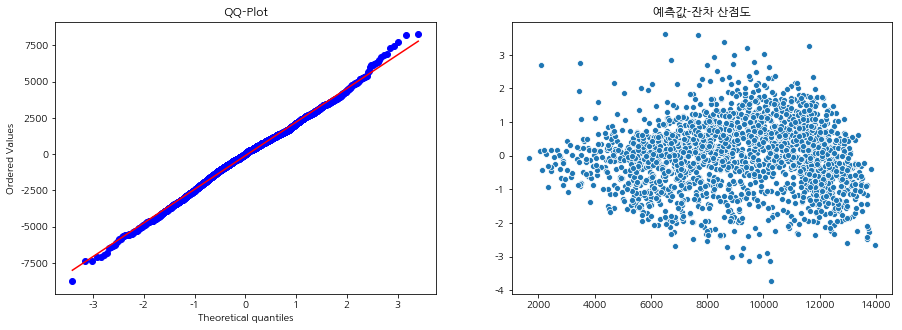

잔차 정규성 검정: 0.014
잔차 등분산성 검정:  0.000000
잔차 독립성 검정: 1.119


In [316]:
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import zscore, probplot

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# 정규성 분석: qq-plot+jarque_bera
stats, p1, skew, kurt = jarque_bera(model.resid)
probplot(model.resid, plot=ax[0])

# 등분산성 + 선형성 분석: het_breuschpaganb 
stat, p2, fstat, fpvv = het_breuschpagan(model.resid, d8[d8.columns[:-1]].values)
fitted = model.fittedvalues

#표준화잔차 사용
sns.scatterplot(x=fitted, y=zscore(model.resid), ax=ax[1])

# 독립성 분석: durbin_watson
dw = durbin_watson(model.resid)
ax[0].set_title("QQ-Plot")
ax[1].set_title('예측값-잔차 산점도')
plt.show()

print(f"잔차 정규성 검정: {p1:.3f}")
print(f"잔차 등분산성 검정: {p2: 3f}")
print(f"잔차 독립성 검정: {dw:.3f}")

잔차검정 결과이다.  

정규성 검정은 jarque_bera, 등분산성 검정은 Breusch–Pagan, 선형성 검정은 예측값과 잔차의 분포를 확인하였으며, 독립성 검정은 durbin_watson을 활용하였다.  

- 정규성: 만족(jarque_bera의 p-value가 귀무가설을 기각하기는 하였으나 상단 outterlier로 예상되는 일부 point를 제외하고는 대체로 직선 상에 분포되므로)
- 등분산성: 불만족(x축이 커지면서 분산(세로축)이 증가하는 경향
- 선형성: 만족(잔차가 무작위 분포되었으며 특정 패턴 미식별)
- 독립성: 값이 1.119이므로 양의 자기상관을 가짐
  - 2에 가까우면 독립, 0에 가까우면 양의 자기상관, 4에 가까우면 음의자기상관

## 8.2 
8.1의 모델의 회귀계수를 활용하여 temperature : 10.5 , wind : 8.2 , precipitation : 3.5 일때 user_counts를 예측하시오

In [328]:
coef = round(model.params, 2).values

x = [1, 10.5, 8.2, 3.5] #맨 앞의 1은 bias

user_cnt = sum(coef*x)

new_x = pd.DataFrame([x[1:]], columns=d8.columns[:-1])

print(f"user 수 예측: {user_cnt}")
print(f"모델예측: {model.predict(new_x).values[0]}")

user 수 예측: 7412.192999999999
모델예측: 7412.2395372465735


## 9
지하철 호선과 월별, 승객 수 간 상관관계가 있는지 확인(Type III Anova 사용)  
- 주효과 뿐만이 아니라 교호작용 분석도 필요할 경우 사용

In [115]:
d9= pd.read_csv('https://github.com/johyunkang/adp_certificate/files/10883822/subway.csv')
d9.head()

,line,month,total
0,1,1,1310
1,1,2,1300
2,1,3,1305
3,1,4,1200
4,1,5,1301


여기서 line, month는 독립적인 명목변수, 설명변수이며 각각 3, 12개의 그룹이 있고, total은 연속형 변수이며 종속변수이다.  

따라서 모수추정을 위한 가정을 만족한다면  모수인자가 2개이며 각각 3개 이상 집단을 가지므로 two-way anova를 사용할 수 있을 것이다. 

- 정규성: shapiro 검정 후 귀무가설 충족 시
- 독립성: 잔차분석은 가능하지만 독립적으로 수집되었다고 가정하고 만족한다고 봄
- 등분산성: levene 검정 후 귀무가설 충족 시

In [156]:
from scipy.stats import shapiro, levene
from statsmodels.stats.stattools import durbin_watson

line_g = [d9[d9['line'] == i]['total'] for i in range(1, 4)]
m_g = [d9[d9['month'] == i]['total'] for i in range(1, 12)]

s1, s2 = [], [] #샤피로
print("[정규성 검정: shapiro]")
for i, g in enumerate(line_g):
    stat, p = shapiro(g)
    s1.append(p)
for i, g in enumerate(m_g):
    stat, p = shapiro(g)
    s2.append(p)

print(f"라인: {all(s >= 0.05 for s in s1)}")
print(f"월: {all(s >= 0.05 for s in s2)}")


print("\n[등분산성 검정: levene]")
stat1, p1 = levene(*line_g)
stat2, p2 = levene(*m_g)

print(f"라인: {p1 >= 0.05}")
print(f"월: {p2 >= 0.05}")

[정규성 검정: shapiro]
라인: False
월: False

[등분산성 검정: levene]
라인: False
월: True


## 9.1 
귀무가설과 대립가설 설정하라

유의수준 5% 하에서 가설을 설정한다.  
각 독립변수의 주효과와 두 독립변수간 교호작용 효과로 나뉠 수 있는데 교호작용 효과가 유의하다면  
주효과 분석에 영향을 주므로 신중하게 접근해야 한다. 

- 귀무가설
    - 주효과1: 라인에 따라 승객수의 차이가 없다.
    - 주효과2: 월에 따라 승객수의 차이가 없다.
    - 교호: 라인과 월 별 상호작용 효과가 없다.


- 대립가설- 귀무가설
    - 주효과1: 라인에 따라 승객수의 차이가 있다.  
    - 주효과2: 월에 따라 승객수의 차이가 있다. 
    - 교호: 라인과 월 별 상호작용 효과가 있다.

## 9.2 
통계량을 구하고, 대립가설 채택여부를 기술하라

In [161]:
import statsmodels.formula.api as smf 
from statsmodels.stats.anova import anova_lm

d9[['line', 'month']] = d9[['line', 'month']].astype('object')

model = smf.ols(formula='total~C(line)*C(month)', 
               data=d9).fit()

anova_3 = anova_lm(model, typ=3)

print(anova_3)

                        sum_sq    df             F        PR(>F)
Intercept         3.466344e+06   1.0  33455.335657  4.849033e-55
C(line)           1.336630e+05   2.0    645.022520  6.417946e-29
C(month)          3.942483e+04  11.0     34.591616  7.896179e-16
C(line):C(month)  9.696908e+04  22.0     42.540665  1.582232e-19
Residual          3.730000e+03  36.0           NaN           NaN


- sum_sq (Sum of Squares): 해당 요인이 설명하는 변동량(제곱합), 값이 클수록 해당 요인의 영향이 큼.
- df (Degrees of Freedom): 자유도, 각 요인 수준의 개수와 관련.
- F: 그룹 간 분산 대 그룹 내(오차) 분산 비율 (F-통계량). 값이 클수록 귀무가설 기각 가능성 높음.
- PR(>F): p-value, 귀무가설(“해당 요인은 효과가 없다”)이 맞을 확률.

먼저 두 설명변수의 교호작용을 확인한다.  
p-value가 1.582232e-19 이므로 충분히 작으므로 유의수준 5% 하에서 귀무가설을 기각한다.  
따라서 라인과 월 간에는 상호관계가 있다.  
이는 각 설명변수의 주효과에 영향을 주게 되므로 제대로 주효과에 대한 분석을 수행할 수 없다.   

주효과 분석은 의미가 없지만 모델 결과만을 보고 해석했을 때  
- 라인에 따라 승객 수의 차이가 있다.(귀무가설 기각)
- 월에 따라 승객 수의 차이가 있다. (귀무가설 기각)   

각 독립변수 간 주효과가 유의한지 확인하기 위해 추가적으로 plot을 그려서 각 독립변수의 종속변수 변화를 확인한다.

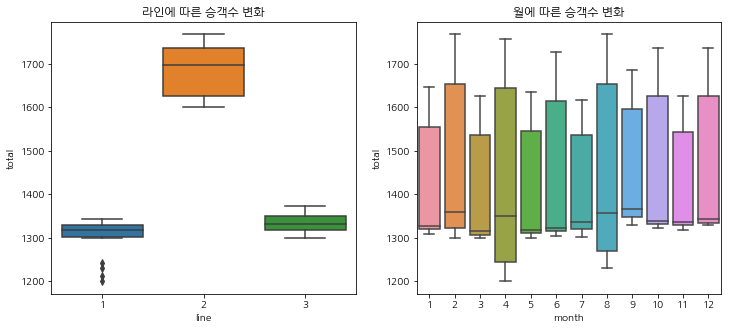

In [183]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

sns.boxplot(data=d9, x='line', y='total', ax=ax[0])
ax[0].set_title('라인에 따른 승객수 변화')

sns.boxplot(data=d9, x='month', y='total', ax=ax[1])
ax[1].set_title('월에 따른 승객수 변화')
plt.show()

- 라인: 라인 2와 나머지 라인 간에는 승객 수의 차이가 확연하지만, 1-3라인 간에는 모호하다.  
- 월(중앙값 기준): 각 월 변화에 따라 승객수가 차이가 있어 보이지만 편차가 크며 구분이 쉽지 않다.